In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\adin\Downloads\data (2).csv")
df.head()

,mic,symbol,isin,date,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
0,XZAG,CBX,HRZB00ICBEX6,2015-12-30,1689.22,1689.71,1673.62,1689.63,-0.02,2017520.82
1,XZAG,CBX,HRZB00ICBEX6,2015-12-29,1675.79,1691.02,1673.37,1689.94,0.84,1094356.06
2,XZAG,CBX,HRZB00ICBEX6,2015-12-28,1655.92,1677.17,1652.76,1675.88,1.21,1125687.29
3,XZAG,CBX,HRZB00ICBEX6,2015-12-23,1647.66,1655.77,1641.41,1655.77,0.49,592284.75
4,XZAG,CBX,HRZB00ICBEX6,2015-12-22,1655.71,1655.71,1642.60,1647.67,-0.55,2714509.05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mic                           1498 non-null   str    
 1   symbol                        1498 non-null   str    
 2   isin                          1498 non-null   str    
 3   date                          1498 non-null   str    
 4   open_value                    1497 non-null   float64
 5   high_value                    1497 non-null   float64
 6   low_value                     1497 non-null   float64
 7   last_value                    1497 non-null   float64
 8   change_prev_close_percentage  1497 non-null   float64
 9   turnover                      1498 non-null   float64
dtypes: float64(6), str(4)
memory usage: 117.2 KB


In [5]:
df.describe()

,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
count,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1.498000e+03
mean,1867.097361,1874.344282,1858.053434,1866.778049,-0.008884,1.492040e+06
std,170.797900,172.179286,169.317824,170.731370,0.715901,1.872377e+06
min,1619.750000,1622.370000,1612.690000,1619.350000,-4.660000,0.000000e+00
25%,1748.210000,1754.180000,1740.370000,1748.150000,-0.380000,7.234300e+05
50%,1809.870000,1816.020000,1801.010000,1809.590000,-0.020000,1.085926e+06
75%,1923.760000,1929.020000,1915.440000,1923.540000,0.370000,1.632190e+06
max,2334.960000,2338.310000,2323.920000,2333.760000,8.940000,3.058814e+07


In [6]:
df.columns

Index(['mic', 'symbol', 'isin', 'date', 'open_value', 'high_value',
       'low_value', 'last_value', 'change_prev_close_percentage', 'turnover'],
      dtype='str')

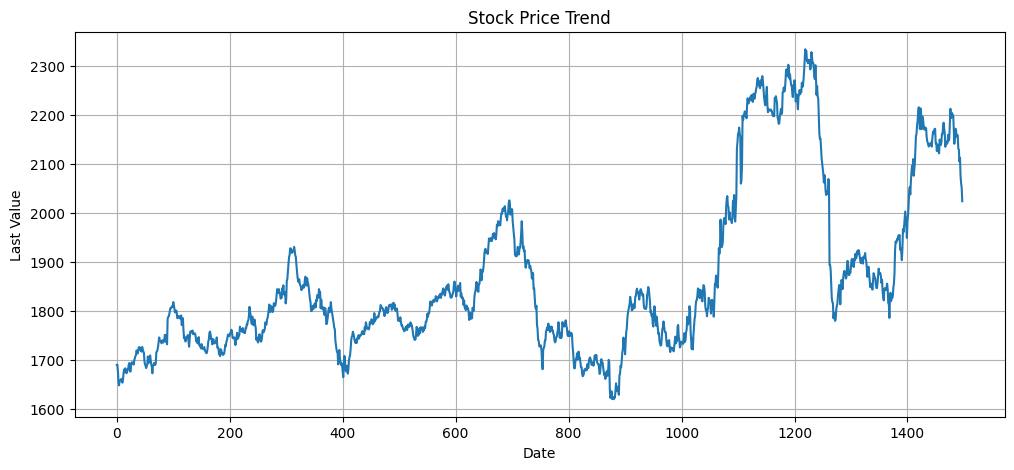

In [11]:
# Trend Analysis

plt.figure(figsize=(12,5))
plt.plot(df.index, df['last_value'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Last Value")
plt.grid(True)
plt.show()

<class 'pandas.DatetimeIndex'>


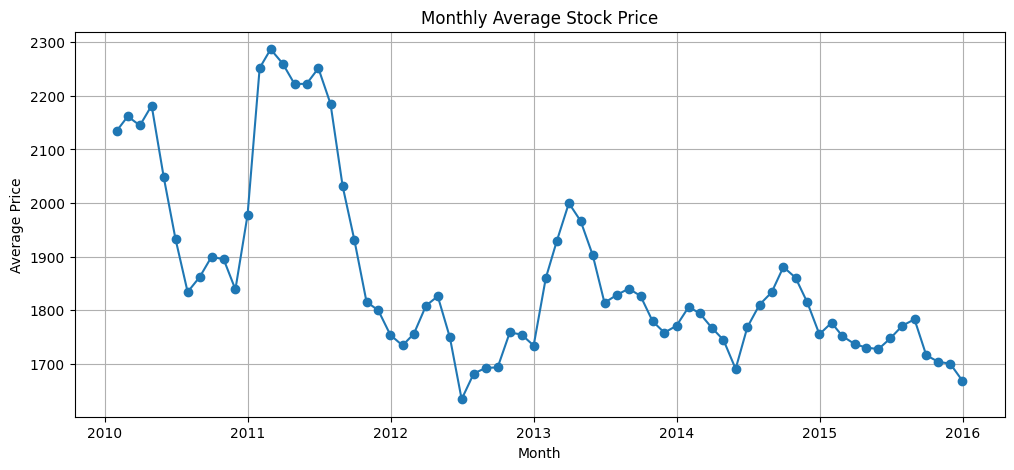

In [23]:
# Monthly Average Price

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df.set_index('date', inplace=True)

# Check index type
print(type(df.index))

# Monthly average
monthly_avg = df['last_value'].resample('ME').mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index, monthly_avg, marker='o')
plt.title("Monthly Average Stock Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

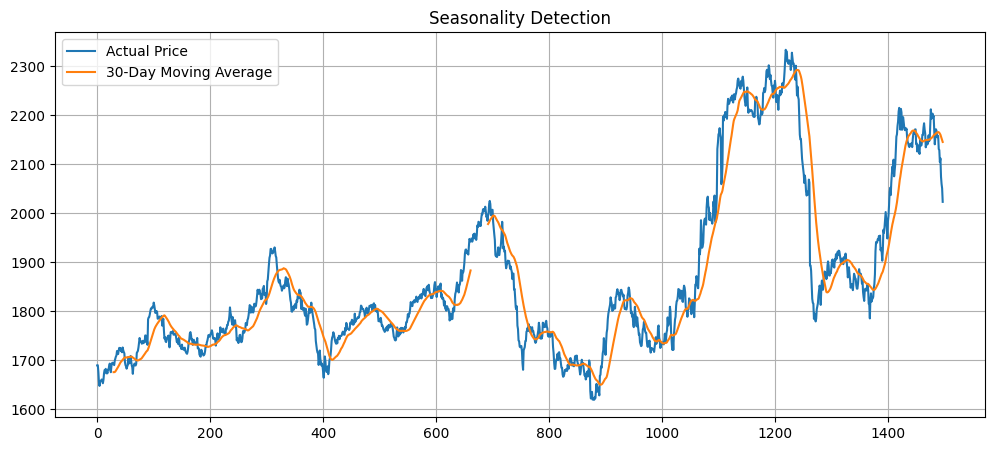

In [14]:
# 2. Seasonality Detection

df['30_Day_MA'] = df['last_value'].rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(df.index, df['last_value'], label='Actual Price')
plt.plot(df.index, df['30_Day_MA'], label='30-Day Moving Average')
plt.legend()
plt.title("Seasonality Detection")
plt.grid(True)
plt.show()

C:\Users\adin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


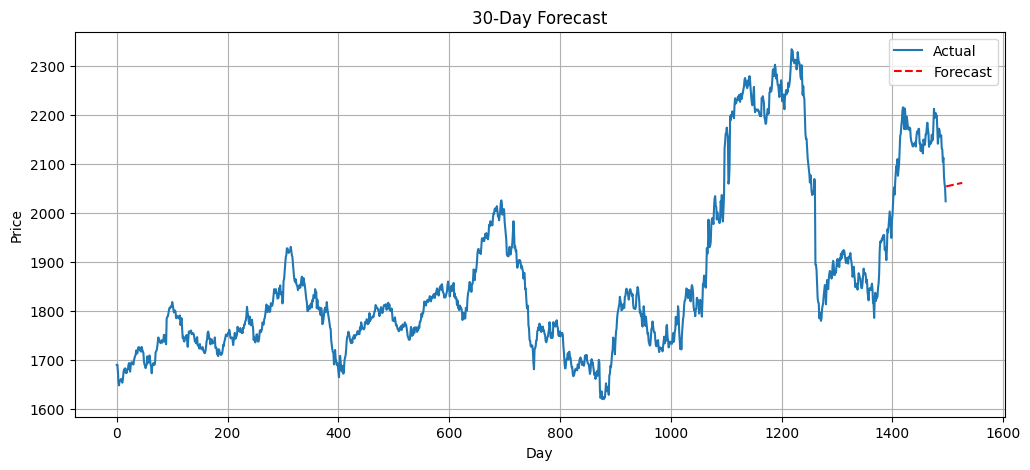

In [24]:
# Forecast Future Values

# Remove rows with missing values
df = df.dropna(subset=['last_value'])

# Reset index
df = df.reset_index(drop=True)

# Create day number
df['Day'] = np.arange(len(df))

X = df[['Day']]
y = df['last_value']

model = LinearRegression()
model.fit(X, y)

future_days = np.arange(len(df), len(df)+30).reshape(-1,1)
future_predictions = model.predict(future_days)

plt.figure(figsize=(12,5))
plt.plot(df['Day'], y, label='Actual')
plt.plot(future_days, future_predictions, 'r--', label='Forecast')
plt.title("30-Day Forecast")
plt.xlabel("Day")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Insights

print("\n===== Time Series Insights =====")
print("1. The stock price trend shows movement over time.")
print("2. Monthly average highlights long-term trends.")
print("3. The 30-day moving average smooths daily fluctuations.")
print("4. Linear Regression provides a simple forecast for the next 30 days.")


===== Time Series Insights =====
1. The stock price trend shows movement over time.
2. Monthly average highlights long-term trends.
3. The 30-day moving average smooths daily fluctuations.
4. Linear Regression provides a simple forecast for the next 30 days.
